# ARC-v0.11 Local — M3 Max System Cost and Pareto Audit

## Purpose

This notebook is the **primary local systems benchmark** for ARC-v0.11.

It is designed for a controlled Apple Silicon environment, specifically an Apple M3 Max MacBook Pro,
using local SSD artifacts only.

ARC-v0.10 remains frozen. This notebook does **not** retrain the predictor, modify thresholds, change
budgets, alter validation assignments, or recompute effectiveness labels.

The system question is:

> How much measured runtime cost is required to recover the utility benefit obtained by selective
> high-fidelity feedback?

Primary outputs:

- local CPU hardware / OS / Python / FAISS audit;
- PQ32 / SQ8 index footprint;
- PQ32 / SQ8 query latency p50 / p95 / p99;
- batch QPS / throughput;
- end-to-end policy runtime;
- RSS memory before/after benchmark;
- quality–latency Pareto;
- primary 25% operating-point cost decision;
- machine-readable CSV / JSON results;
- SHA-256 integrity seal.

## Benchmark discipline

- Local SSD only.
- No Google Drive / network filesystem in timed regions.
- Apple CPU only.
- Fixed FAISS thread count.
- Warm-up before measurement.
- Randomized policy order across repetitions.
- Exact ARC-v0.10 frozen selectors.
- No post-hoc threshold tuning.


## 0. Local artifact layout

Before running, place the required artifacts under a local directory.

Recommended layout:

```text
~/ARC_benchmark/
├── indexes/
│   ├── hotpotqa-v3-5233329d-bge-small-ivfpq-nlist4096-m32-nbits8-seed20260816.faiss
│   └── hotpotqa-v3-5233329d-bge-small-ivfsq8-nlist4096-seed20260816.faiss
├── hotpotqa/
│   ├── stage1/
│   │   ├── query_embeddings.float32.npy
│   │   ├── query_ids.utf8.txt
│   │   ├── official_split_manifest.json
│   │   └── corpus-embedding-shards-v3/
│   │       ├── manifest.json
│   │       └── ...
│   └── ...
└── arc-v0/
    └── boundary-aware-selective-fidelity-v010/
        └── <completed-run>/
            ├── report.json
            └── mitigation_query_outcomes.parquet
```

The notebook deliberately fails closed if any required artifact is missing.


In [1]:
# Install once in the local Python environment if needed.
# In Jupyter, uncomment:
#
# %pip install -q faiss-cpu==1.12.0 psutil pyarrow pandas numpy matplotlib


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import gc
import time
import platform
import random
import subprocess
import statistics

import numpy as np
import pandas as pd
import faiss
import psutil
import matplotlib.pyplot as plt

print("Platform:", platform.platform())
print("Machine :", platform.machine())
print("Python  :", platform.python_version())
print("CPU count:", os.cpu_count())
print("RAM GB  :", psutil.virtual_memory().total / 1024**3)
print("FAISS   :", faiss.__version__)
print("NumPy   :", np.__version__)


Platform: macOS-26.6.1-arm64-arm-64bit
Machine : arm64
Python  : 3.12.13
CPU count: 14
RAM GB  : 36.0
FAISS   : 1.12.0
NumPy   : 2.0.2


## 1. Fixed benchmark configuration


In [3]:
SEED = 20260816

DIM = 384
N_DOCS = 5_233_329
NPROBE = 64
TOP_RETRIEVE = 100
MAX_ROUNDS = 4

# Primary local CPU benchmark.
FAISS_THREADS = 8

# Increase to 10 later if runtime is still reasonable.
REPETITIONS = 5

WARMUP_QUERIES = 200
LATENCY_SAMPLE_SIZE = 500

EXPECTED_VALIDATION_QUERIES = 2694

BUDGETS = [0.10, 0.25, 0.50]
PRIMARY_BUDGET = 0.25

FROZEN_CONFIGS = [
    {
        "method": "mean",
        "k": 20,
        "alpha": 0.3,
        "temperature": None,
    },
    {
        "method": "softmax",
        "k": 5,
        "alpha": 0.5,
        "temperature": 0.1,
    },
]

# ------------------------------------------------------------------
# Change ONLY this root to your local SSD location.
# ------------------------------------------------------------------
LOCAL_ROOT = Path.home() / "ARC_benchmark"

INDEX_ROOT = LOCAL_ROOT / "indexes"
HOTPOT_ROOT = LOCAL_ROOT / "hotpotqa"
ARC_ROOT = LOCAL_ROOT / "arc-v0"

SHARD_ROOT = HOTPOT_ROOT / "stage1/corpus-embedding-shards-v3"
SHARD_MANIFEST = SHARD_ROOT / "manifest.json"

QUERY_EMB = HOTPOT_ROOT / "stage1/query_embeddings.float32.npy"
QUERY_IDS = HOTPOT_ROOT / "stage1/query_ids.utf8.txt"
SPLIT_MANIFEST = HOTPOT_ROOT / "stage1/official_split_manifest.json"

PQ32_PATH = INDEX_ROOT / (
    "hotpotqa-v3-5233329d-bge-small-"
    "ivfpq-nlist4096-m32-nbits8-seed20260816.faiss"
)

SQ8_PATH = INDEX_ROOT / (
    "hotpotqa-v3-5233329d-bge-small-"
    "ivfsq8-nlist4096-seed20260816.faiss"
)

V010_BASE = ARC_ROOT / "boundary-aware-selective-fidelity-v010"

V010_RUNS = sorted(
    [
        p
        for p in V010_BASE.glob("*")
        if (p / "report.json").is_file()
        and (
            p
            / "posthoc-selector-reconstruction"
            / "v010_reconstructed_boundary_selector_assignments.parquet"
        ).is_file()
        and (
            p
            / "posthoc-selector-reconstruction"
            / "v010_boundary_selector_reconstruction_audit.json"
        ).is_file()
    ],
    key=lambda p: p.stat().st_mtime,
)

if not V010_RUNS:
    raise FileNotFoundError(
        "No completed local ARC-v0.10 run with sealed selector reconstruction "
        "artifacts was found."
    )

V010_RUN = V010_RUNS[-1]
V010_REPORT = V010_RUN / "report.json"

V010_RECON_DIR = (
    V010_RUN
    / "posthoc-selector-reconstruction"
)

V010_SELECTOR_ASSIGNMENTS = (
    V010_RECON_DIR
    / "v010_reconstructed_boundary_selector_assignments.parquet"
)

V010_SELECTOR_AUDIT = (
    V010_RECON_DIR
    / "v010_boundary_selector_reconstruction_audit.json"
)

V010_SELECTOR_AUDIT_SHA = (
    V010_RECON_DIR
    / "RECONSTRUCTION_AUDIT_SHA256.txt"
)

OUT_ROOT = ARC_ROOT / "system-cost-pareto-audit-v011-local-m3max"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
OUT = OUT_ROOT / RUN_ID
OUT.mkdir(parents=True, exist_ok=False)

faiss.omp_set_num_threads(FAISS_THREADS)

print("LOCAL_ROOT:", LOCAL_ROOT)
print("v0.10 source:", V010_RUN)
print("v0.11 output:", OUT)
print("FAISS threads:", faiss.omp_get_max_threads())


LOCAL_ROOT: /Users/ravan/ARC_benchmark
v0.10 source: /Users/ravan/ARC_benchmark/arc-v0/boundary-aware-selective-fidelity-v010/20260816-205143
v0.11 output: /Users/ravan/ARC_benchmark/arc-v0/system-cost-pareto-audit-v011-local-m3max/20260817-111833
FAISS threads: 8


## 2. Hardware audit


In [4]:
def shell(cmd):
    try:
        return subprocess.check_output(
            cmd,
            shell=True,
            text=True,
            stderr=subprocess.STDOUT,
        ).strip()
    except Exception as e:
        return f"ERROR: {e}"

hardware = {
    "platform": platform.platform(),
    "machine": platform.machine(),
    "python_version": platform.python_version(),
    "cpu_count_logical": os.cpu_count(),
    "ram_gb": psutil.virtual_memory().total / 1024**3,
    "faiss_version": faiss.__version__,
    "faiss_threads": faiss.omp_get_max_threads(),
    "numpy_version": np.__version__,
    "mac_model": shell("system_profiler SPHardwareDataType | grep 'Model Name'"),
    "chip": shell("system_profiler SPHardwareDataType | grep 'Chip'"),
    "memory": shell("system_profiler SPHardwareDataType | grep 'Memory'"),
    "macos": shell("sw_vers"),
}

print(json.dumps(hardware, indent=2))


{
  "platform": "macOS-26.6.1-arm64-arm-64bit",
  "machine": "arm64",
  "python_version": "3.12.13",
  "cpu_count_logical": 14,
  "ram_gb": 36.0,
  "faiss_version": "1.12.0",
  "faiss_threads": 8,
  "numpy_version": "2.0.2",
  "mac_model": "2026-08-17 19:18:33.379 system_profiler[99276:4383324] hw.cpufamily: 0x72015832\n      Model Name: MacBook Pro",
  "chip": "2026-08-17 19:18:33.526 system_profiler[99280:4383343] hw.cpufamily: 0x72015832\n      Chip: Apple M3 Max",
  "memory": "2026-08-17 19:18:33.694 system_profiler[99284:4383366] hw.cpufamily: 0x72015832\n      Memory: 36 GB",
  "macos": "ProductName:\t\tmacOS\nProductVersion:\t\t26.6.1\nBuildVersion:\t\t25G76"
}


## 3. Artifact audit and fail-closed validation


In [5]:
required = {
    "SHARD_MANIFEST": SHARD_MANIFEST,
    "QUERY_EMB": QUERY_EMB,
    "QUERY_IDS": QUERY_IDS,
    "SPLIT_MANIFEST": SPLIT_MANIFEST,
    "PQ32_INDEX": PQ32_PATH,
    "SQ8_INDEX": SQ8_PATH,
    "V010_REPORT": V010_REPORT,
    "V010_SELECTOR_ASSIGNMENTS": V010_SELECTOR_ASSIGNMENTS,
    "V010_SELECTOR_AUDIT": V010_SELECTOR_AUDIT,
    "V010_SELECTOR_AUDIT_SHA": V010_SELECTOR_AUDIT_SHA,
}

for name, path in required.items():
    print(f"{name:24s}", "OK" if path.is_file() else "MISSING", path)
    if not path.is_file():
        raise FileNotFoundError(path)


SHARD_MANIFEST           OK /Users/ravan/ARC_benchmark/hotpotqa/stage1/corpus-embedding-shards-v3/manifest.json
QUERY_EMB                OK /Users/ravan/ARC_benchmark/hotpotqa/stage1/query_embeddings.float32.npy
QUERY_IDS                OK /Users/ravan/ARC_benchmark/hotpotqa/stage1/query_ids.utf8.txt
SPLIT_MANIFEST           OK /Users/ravan/ARC_benchmark/hotpotqa/stage1/official_split_manifest.json
PQ32_INDEX               OK /Users/ravan/ARC_benchmark/indexes/hotpotqa-v3-5233329d-bge-small-ivfpq-nlist4096-m32-nbits8-seed20260816.faiss
SQ8_INDEX                OK /Users/ravan/ARC_benchmark/indexes/hotpotqa-v3-5233329d-bge-small-ivfsq8-nlist4096-seed20260816.faiss
V010_REPORT              OK /Users/ravan/ARC_benchmark/arc-v0/boundary-aware-selective-fidelity-v010/20260816-205143/report.json
V010_SELECTOR_ASSIGNMENTS OK /Users/ravan/ARC_benchmark/arc-v0/boundary-aware-selective-fidelity-v010/20260816-205143/posthoc-selector-reconstruction/v010_reconstructed_boundary_selector_assignments.

In [6]:
def sha256_file(path, chunk_size=64*1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

with open(V010_REPORT, "r", encoding="utf-8") as f:
    v010 = json.load(f)

assert v010["status"] == "ARC_V010_BOUNDARY_AWARE_SELECTIVE_FIDELITY_COMPLETE"
assert v010["test_accessed"] is False
assert int(v010["validation_queries"]) == EXPECTED_VALIDATION_QUERIES

print("v0.10 report SHA:", sha256_file(V010_REPORT))
print("v0.10 protocol SHA:", v010["protocol_sha256"])


v0.10 report SHA: fdf64925334500bc4823fd828510d9a3ec946719fda940cc8eabd55a8cd44589
v0.10 protocol SHA: a48d2efbd470314de1042c85d8888312b3f61d1c68d3456f6f91a3150320817f


## 4. Seal local v0.11 protocol


In [7]:
protocol = {
    "schema_version": 1,
    "status": "SEALED_BEFORE_LOCAL_M3MAX_V011_BENCHMARK",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_v010_report_sha256": sha256_file(V010_REPORT),
    "source_v010_protocol_sha256": v010["protocol_sha256"],
    "hardware": hardware,
    "local_ssd_only": True,
    "cpu_only": True,
    "faiss_threads": FAISS_THREADS,
    "warmup_queries": WARMUP_QUERIES,
    "latency_sample_size": LATENCY_SAMPLE_SIZE,
    "repetitions": REPETITIONS,
    "validation_queries": EXPECTED_VALIDATION_QUERIES,
    "nprobe": NPROBE,
    "top_retrieve": TOP_RETRIEVE,
    "feedback_rounds": MAX_ROUNDS,
    "budgets": BUDGETS,
    "primary_budget": PRIMARY_BUDGET,
    "predictor_retraining_allowed": False,
    "threshold_retuning_allowed": False,
    "validation_assignment_changes_allowed": False,
    "selector_provenance": "deterministic post-hoc reconstruction from frozen ARC-v0.9/v0.10 artifacts",
    "selector_assignment_sha256": sha256_file(V010_SELECTOR_ASSIGNMENTS),
    "selector_audit_sha256": sha256_file(V010_SELECTOR_AUDIT),
    "test_access_allowed": False,
}

canonical = json.dumps(
    protocol,
    sort_keys=True,
    separators=(",", ":"),
).encode("utf-8")

protocol_sha = hashlib.sha256(canonical).hexdigest()
protocol["protocol_sha256"] = protocol_sha

(OUT / "v011_local_m3max_protocol.json").write_text(
    json.dumps(protocol, indent=2),
    encoding="utf-8",
)

print("Protocol SHA-256:", protocol_sha)


Protocol SHA-256: 1338e43bb8defa59778e59158bff0ae93754108d12686156a1a2e35d6a30a24f


## 5. Load validation queries


In [8]:
with open(SHARD_MANIFEST, "r", encoding="utf-8") as f:
    shard_manifest = json.load(f)

assert shard_manifest["status"] == "CORPUS_EMBEDDING_SHARDS_COMPLETE"

shards = sorted(
    shard_manifest["shards"],
    key=lambda x: int(x["shard_id"]),
)

SHARD_ENDS = np.asarray(
    [int(s["end_row"]) for s in shards],
    dtype=np.int64,
)

queries = np.load(
    QUERY_EMB,
    mmap_mode="r",
)

with open(QUERY_IDS, "r", encoding="utf-8") as f:
    query_ids = [x.strip() for x in f if x.strip()]

with open(SPLIT_MANIFEST, "r", encoding="utf-8") as f:
    split = json.load(f)

dev_ids = [str(x) for x in split["dev_query_ids"]]

assert len(dev_ids) == 5447
assert split["test_qrels_relevance_values_accessed"] is False
assert split["test_retrieval_performed"] is False
assert split["test_outcomes_observed"] is False

def split_bucket(qid):
    h = hashlib.sha256(str(qid).encode("utf-8")).digest()
    return int.from_bytes(h[:8], "big") % 2

validation_ids = [
    qid
    for qid in dev_ids
    if split_bucket(qid) == 1
]

assert len(validation_ids) == EXPECTED_VALIDATION_QUERIES

query_row = {
    qid: i
    for i, qid in enumerate(query_ids)
}

validation_rows = np.asarray(
    [query_row[qid] for qid in validation_ids],
    dtype=np.int64,
)

Q_VAL = np.asarray(
    queries[validation_rows],
    dtype=np.float32,
)

Q_VAL /= np.maximum(
    np.linalg.norm(Q_VAL, axis=1, keepdims=True),
    1e-12,
)

print("Validation queries:", len(validation_ids))
print("Q_VAL:", Q_VAL.shape)


Validation queries: 2694
Q_VAL: (2694, 384)


## 6. Feedback helpers


In [9]:
def load_rows_from_shards(rows):
    rows = np.asarray(rows, dtype=np.int64)
    shape = rows.shape
    flat = rows.reshape(-1)

    unique_rows, inverse = np.unique(
        flat,
        return_inverse=True,
    )

    shard_ids = np.searchsorted(
        SHARD_ENDS,
        unique_rows,
        side="right",
    )

    vectors = np.empty(
        (len(unique_rows), DIM),
        dtype=np.float32,
    )

    for sid in np.unique(shard_ids):
        mask = shard_ids == sid
        start = int(shards[int(sid)]["start_row"])
        local = unique_rows[mask] - start

        arr = np.load(
            SHARD_ROOT / shards[int(sid)]["file"],
            mmap_mode="r",
        )

        vectors[mask] = np.asarray(
            arr[local],
            dtype=np.float32,
        )

    return vectors[inverse].reshape(*shape, DIM)

def normalize_rows(x):
    x = np.asarray(x, np.float32)
    return x / np.maximum(
        np.linalg.norm(x, axis=1, keepdims=True),
        1e-12,
    )

def feedback_matrix(ids, scores, cfg):
    k = int(cfg["k"])
    x = load_rows_from_shards(
        np.asarray(ids[:, :k], np.int64)
    )

    if cfg["method"] == "mean":
        f = x.mean(axis=1)
    else:
        z = np.asarray(scores[:, :k], np.float64) / float(cfg["temperature"])
        z -= z.max(axis=1, keepdims=True)
        w = np.exp(np.clip(z, -60, 60))
        w /= np.maximum(w.sum(axis=1, keepdims=True), 1e-12)
        f = (x * w[:, :, None]).sum(axis=1)

    return normalize_rows(f)

def anchored_update(q0, f, alpha):
    return normalize_rows(
        (1.0 - float(alpha)) * q0
        + float(alpha) * f
    )

def cfg_key(cfg):
    temp = "none" if cfg["temperature"] is None else str(cfg["temperature"]).replace(".", "p")
    return (
        f"{cfg['method']}"
        f"-k{cfg['k']}"
        f"-a{str(cfg['alpha']).replace('.', 'p')}"
        f"-t{temp}"
    )


## 7. Load indexes into memory before timing


In [10]:
process = psutil.Process(os.getpid())

rss_before_indexes = process.memory_info().rss

load_start = time.perf_counter()

PQ32_INDEX = faiss.read_index(str(PQ32_PATH))
SQ8_INDEX = faiss.read_index(str(SQ8_PATH))

PQ32_INDEX.nprobe = NPROBE
SQ8_INDEX.nprobe = NPROBE

index_load_seconds = time.perf_counter() - load_start

rss_after_indexes = process.memory_info().rss

assert PQ32_INDEX.ntotal == N_DOCS
assert SQ8_INDEX.ntotal == N_DOCS

print("Index load seconds:", index_load_seconds)
print("PQ32 GiB:", PQ32_PATH.stat().st_size / 1024**3)
print("SQ8 GiB:", SQ8_PATH.stat().st_size / 1024**3)
print("RSS before indexes GiB:", rss_before_indexes / 1024**3)
print("RSS after indexes GiB :", rss_after_indexes / 1024**3)
print("RSS delta GiB         :", (rss_after_indexes-rss_before_indexes) / 1024**3)


Index load seconds: 0.4301625410153065
PQ32 GiB: 0.20121296867728233
SQ8 GiB: 1.9164685606956482
RSS before indexes GiB: 0.2179107666015625
RSS after indexes GiB : 2.3828887939453125
RSS delta GiB         : 2.16497802734375


## 8. Warm-up


In [11]:
warm = np.ascontiguousarray(
    Q_VAL[:WARMUP_QUERIES],
    np.float32,
)

for name, index in [
    ("PQ32", PQ32_INDEX),
    ("SQ8", SQ8_INDEX),
]:
    for _ in range(3):
        index.search(
            warm,
            TOP_RETRIEVE,
        )

    print("Warm-up complete:", name)


Warm-up complete: PQ32
Warm-up complete: SQ8


## 9. Batch throughput benchmark


In [12]:
print("Q_VAL:", Q_VAL.shape)
print("REPETITIONS:", REPETITIONS)
print("TOP_RETRIEVE:", TOP_RETRIEVE)
print("FAISS threads:", faiss.omp_get_max_threads())

Q_VAL: (2694, 384)
REPETITIONS: 5
TOP_RETRIEVE: 100
FAISS threads: 8


In [13]:
def benchmark_index(index, name):
    rng = np.random.default_rng(SEED)
    rows = []

    for rep in range(REPETITIONS):
        order = rng.permutation(len(Q_VAL))
        q = np.ascontiguousarray(
            Q_VAL[order],
            np.float32,
        )

        t0 = time.perf_counter()

        index.search(
            q,
            TOP_RETRIEVE,
        )

        elapsed = time.perf_counter() - t0

        rows.append({
            "retriever": name,
            "repetition": rep,
            "query_count": len(q),
            "elapsed_seconds": elapsed,
            "qps": len(q) / elapsed,
            "ms_per_query": 1000 * elapsed / len(q),
        })

    return pd.DataFrame(rows)

micro_df = pd.concat([
    benchmark_index(PQ32_INDEX, "PQ32"),
    benchmark_index(SQ8_INDEX, "SQ8"),
], ignore_index=True)

display(micro_df)

micro_df.to_csv(
    OUT / "v011_local_retrieval_microbenchmark.csv",
    index=False,
)


,retriever,repetition,query_count,elapsed_seconds,qps,ms_per_query
0,PQ32,0,2694,0.421714,6388.210030,0.156538
1,PQ32,1,2694,0.500831,5379.064030,0.185906
2,PQ32,2,2694,0.479400,5619.529774,0.177951
3,PQ32,3,2694,0.471925,5708.530663,0.175176
4,PQ32,4,2694,0.462646,5823.023015,0.171732
5,SQ8,0,2694,10.245705,262.939454,3.803157
6,SQ8,1,2694,9.852856,273.423257,3.657333
7,SQ8,2,2694,9.765005,275.883105,3.624724
8,SQ8,3,2694,9.804001,274.785769,3.639199
9,SQ8,4,2694,9.328901,288.780006,3.462844


## 10. Query-level latency benchmark


In [14]:
rng = np.random.default_rng(SEED)

latency_positions = rng.choice(
    len(Q_VAL),
    size=min(LATENCY_SAMPLE_SIZE, len(Q_VAL)),
    replace=False,
)

Q_LAT = Q_VAL[latency_positions]

def query_latency_summary(index, name):
    latencies_ms = []

    for q in Q_LAT:
        q1 = np.ascontiguousarray(
            q[None, :],
            np.float32,
        )

        t0 = time.perf_counter()

        index.search(
            q1,
            TOP_RETRIEVE,
        )

        latencies_ms.append(
            1000 * (time.perf_counter() - t0)
        )

    x = np.asarray(
        latencies_ms,
        np.float64,
    )

    return {
        "retriever": name,
        "queries": len(x),
        "mean_ms": float(x.mean()),
        "p50_ms": float(np.quantile(x, 0.50)),
        "p95_ms": float(np.quantile(x, 0.95)),
        "p99_ms": float(np.quantile(x, 0.99)),
        "max_ms": float(x.max()),
    }

latency_df = pd.DataFrame([
    query_latency_summary(PQ32_INDEX, "PQ32"),
    query_latency_summary(SQ8_INDEX, "SQ8"),
])

display(latency_df)

latency_df.to_csv(
    OUT / "v011_local_query_latency_summary.csv",
    index=False,
)


,retriever,queries,mean_ms,p50_ms,p95_ms,p99_ms,max_ms
0,PQ32,500,0.859944,0.814792,0.924035,1.001347,22.424833
1,SQ8,500,25.667500,25.578604,29.659037,32.332597,34.448458


## 11. Exact frozen ARC-v0.10 selector assignments


In [15]:
with open(
    V010_SELECTOR_AUDIT,
    "r",
    encoding="utf-8",
) as f:
    selector_audit = json.load(f)

assert (
    selector_audit["status"]
    == "V010_BOUNDARY_SELECTOR_RECONSTRUCTION_COMPLETE"
)
assert selector_audit["test_accessed"] is False

EXPECTED_ASSIGNMENT_SHA = (
    "33ccee5437aeda90bb759d19146e2be96a78c44c147f0d7ec9fc4cd00e6a9e19"
)

actual_assignment_sha = sha256_file(
    V010_SELECTOR_ASSIGNMENTS
)

print("selector assignment SHA expected:", EXPECTED_ASSIGNMENT_SHA)
print("selector assignment SHA actual  :", actual_assignment_sha)

assert actual_assignment_sha == EXPECTED_ASSIGNMENT_SHA

boundary_assignments = pd.read_parquet(
    V010_SELECTOR_ASSIGNMENTS
)

def selector_from_reconstruction(
    ck,
    budget,
):
    sub = boundary_assignments[
        (boundary_assignments["config_key"] == ck)
        & (
            boundary_assignments["policy"]
            == "boundary_selective_sq8"
        )
        & np.isclose(
            boundary_assignments["nominal_budget"].astype(float),
            float(budget),
        )
    ].copy()

    if len(sub) != EXPECTED_VALIDATION_QUERIES:
        raise RuntimeError(
            f"Unexpected reconstructed selector rows: "
            f"{ck}, {budget}, {len(sub)}"
        )

    sub = sub.set_index("query_id").loc[validation_ids]

    return sub["selected_for_sq8"].astype(bool).to_numpy()

selector_cache = {}

for cfg in FROZEN_CONFIGS:
    ck = cfg_key(cfg)

    for budget in BUDGETS:
        boundary_selector = selector_from_reconstruction(
            ck,
            budget,
        )

        selector_cache[
            (ck, "boundary", budget)
        ] = boundary_selector

        print(
            ck,
            budget,
            "boundary selected:",
            int(boundary_selector.sum()),
            "fraction:",
            float(boundary_selector.mean()),
        )

print("SEALED V0.10 BOUNDARY SELECTORS — LOADED")


selector assignment SHA expected: 33ccee5437aeda90bb759d19146e2be96a78c44c147f0d7ec9fc4cd00e6a9e19
selector assignment SHA actual  : 33ccee5437aeda90bb759d19146e2be96a78c44c147f0d7ec9fc4cd00e6a9e19
mean-k20-a0p3-tnone 0.1 boundary selected: 270 fraction: 0.10022271714922049
mean-k20-a0p3-tnone 0.25 boundary selected: 713 fraction: 0.26466221232368226
mean-k20-a0p3-tnone 0.5 boundary selected: 1417 fraction: 0.5259836674090571
softmax-k5-a0p5-t0p1 0.1 boundary selected: 270 fraction: 0.10022271714922049
softmax-k5-a0p5-t0p1 0.25 boundary selected: 713 fraction: 0.26466221232368226
softmax-k5-a0p5-t0p1 0.5 boundary selected: 1417 fraction: 0.5259836674090571
SEALED V0.10 BOUNDARY SELECTORS — LOADED


## 12. End-to-end policy benchmark with RSS tracking


In [16]:
def simulate_policy_cost(cfg, policy, selector=None):
    q0 = Q_VAL
    q = q0.copy()

    pq_sec = 0.0
    sq_sec = 0.0
    fb_sec = 0.0
    upd_sec = 0.0

    pq_count = 0
    sq_count = 0

    rss_samples = [
        process.memory_info().rss
    ]

    total_start = time.perf_counter()

    for t in range(MAX_ROUNDS + 1):
        t0 = time.perf_counter()

        pq_scores, pq_ids = PQ32_INDEX.search(
            np.ascontiguousarray(q, np.float32),
            TOP_RETRIEVE,
        )

        pq_sec += time.perf_counter() - t0
        pq_count += len(q)

        rss_samples.append(
            process.memory_info().rss
        )

        if t == MAX_ROUNDS:
            break

        t0 = time.perf_counter()

        f = feedback_matrix(
            pq_ids,
            pq_scores,
            cfg,
        )

        fb_sec += time.perf_counter() - t0

        if policy == "always_pq32":
            pass

        elif policy == "always_sq8":
            t0 = time.perf_counter()

            sq_scores, sq_ids = SQ8_INDEX.search(
                np.ascontiguousarray(q, np.float32),
                TOP_RETRIEVE,
            )

            sq_sec += time.perf_counter() - t0
            sq_count += len(q)

            t0 = time.perf_counter()

            f = feedback_matrix(
                sq_ids,
                sq_scores,
                cfg,
            )

            fb_sec += time.perf_counter() - t0

        elif policy in {
            "boundary_selective_sq8",
            "random_selective_sq8",
        }:
            if selector is None:
                raise ValueError("selector required")

            chosen = np.flatnonzero(selector)

            if len(chosen):
                t0 = time.perf_counter()

                sq_scores, sq_ids = SQ8_INDEX.search(
                    np.ascontiguousarray(
                        q[chosen],
                        np.float32,
                    ),
                    TOP_RETRIEVE,
                )

                sq_sec += time.perf_counter() - t0
                sq_count += len(chosen)

                t0 = time.perf_counter()

                f_high = feedback_matrix(
                    sq_ids,
                    sq_scores,
                    cfg,
                )

                fb_sec += time.perf_counter() - t0

                f[chosen] = f_high

        else:
            raise ValueError(policy)

        t0 = time.perf_counter()

        q = anchored_update(
            q0,
            f,
            cfg["alpha"],
        )

        upd_sec += time.perf_counter() - t0

        rss_samples.append(
            process.memory_info().rss
        )

    total = time.perf_counter() - total_start

    return {
        "total_seconds": total,
        "effective_qps": len(Q_VAL) / total,
        "ms_per_validation_query": 1000 * total / len(Q_VAL),
        "pq32_search_seconds": pq_sec,
        "sq8_search_seconds": sq_sec,
        "feedback_build_seconds": fb_sec,
        "update_seconds": upd_sec,
        "pq32_query_searches": pq_count,
        "sq8_query_searches": sq_count,
        "peak_rss_gib": max(rss_samples) / 1024**3,
    }


## 13. Repeated randomized-order policy benchmark


In [17]:
def deterministic_random_selector(
    query_ids,
    config_key,
    budget,
    n_select,
    seed=SEED,
):
    scores = np.asarray(
        [
            int.from_bytes(
                hashlib.sha256(
                    (
                        f"{qid}|"
                        f"{config_key}|"
                        f"{budget}|"
                        f"{seed}"
                    ).encode("utf-8")
                ).digest()[:8],
                "big",
            )
            for qid in query_ids
        ],
        dtype=np.uint64,
    )

    order = np.argsort(scores)

    selected = np.zeros(
        len(query_ids),
        dtype=bool,
    )

    selected[
        order[:n_select]
    ] = True

    return selected


for cfg in FROZEN_CONFIGS:
    ck = cfg_key(cfg)

    for budget in BUDGETS:
        boundary_selector = selector_cache[
            (ck, "boundary", budget)
        ]

        random_selector = deterministic_random_selector(
            validation_ids,
            ck,
            budget,
            int(boundary_selector.sum()),
            SEED,
        )

        assert random_selector.sum() == boundary_selector.sum()

        selector_cache[
            (ck, "random", budget)
        ] = random_selector


policy_specs = []

for cfg in FROZEN_CONFIGS:
    ck = cfg_key(cfg)

    policy_specs.extend([
        (ck, cfg, "always_pq32", np.nan, None),
        (ck, cfg, "always_sq8", np.nan, None),
    ])

    for budget in BUDGETS:
        policy_specs.append(
            (
                ck,
                cfg,
                "boundary_selective_sq8",
                budget,
                selector_cache[(ck, "boundary", budget)],
            )
        )

        policy_specs.append(
            (
                ck,
                cfg,
                "random_selective_sq8",
                budget,
                selector_cache[(ck, "random", budget)],
            )
        )

rng = random.Random(SEED)
rows = []

for rep in range(REPETITIONS):
    order = list(range(len(policy_specs)))
    rng.shuffle(order)

    print(f"=== repetition {rep+1}/{REPETITIONS} ===")

    for idx in order:
        ck, cfg, policy, budget, selector = policy_specs[idx]

        print(
            ck,
            policy,
            budget,
        )

        result = simulate_policy_cost(
            cfg,
            policy,
            selector,
        )

        rows.append({
            "repetition": rep,
            "config_key": ck,
            "policy": policy,
            "budget": budget,
            **result,
        })

        gc.collect()

policy_raw = pd.DataFrame(rows)

display(policy_raw.head())

policy_raw.to_csv(
    OUT / "v011_local_policy_benchmark_raw.csv",
    index=False,
)


=== repetition 1/5 ===
softmax-k5-a0p5-t0p1 boundary_selective_sq8 0.1
softmax-k5-a0p5-t0p1 random_selective_sq8 0.1
mean-k20-a0p3-tnone always_sq8 nan
softmax-k5-a0p5-t0p1 always_pq32 nan
mean-k20-a0p3-tnone random_selective_sq8 0.1
softmax-k5-a0p5-t0p1 random_selective_sq8 0.25
softmax-k5-a0p5-t0p1 always_sq8 nan
mean-k20-a0p3-tnone boundary_selective_sq8 0.1
mean-k20-a0p3-tnone boundary_selective_sq8 0.5
softmax-k5-a0p5-t0p1 boundary_selective_sq8 0.5
mean-k20-a0p3-tnone always_pq32 nan
mean-k20-a0p3-tnone boundary_selective_sq8 0.25
mean-k20-a0p3-tnone random_selective_sq8 0.5
softmax-k5-a0p5-t0p1 boundary_selective_sq8 0.25
mean-k20-a0p3-tnone random_selective_sq8 0.25
softmax-k5-a0p5-t0p1 random_selective_sq8 0.5
=== repetition 2/5 ===
softmax-k5-a0p5-t0p1 random_selective_sq8 0.25
softmax-k5-a0p5-t0p1 always_pq32 nan
softmax-k5-a0p5-t0p1 always_sq8 nan
softmax-k5-a0p5-t0p1 boundary_selective_sq8 0.1
mean-k20-a0p3-tnone random_selective_sq8 0.5
mean-k20-a0p3-tnone always_sq8 nan


,repetition,config_key,policy,budget,total_seconds,effective_qps,ms_per_validation_query,pq32_search_seconds,sq8_search_seconds,feedback_build_seconds,update_seconds,pq32_query_searches,sq8_query_searches,peak_rss_gib
0,0,softmax-k5-a0p5-t0p1,boundary_selective_sq8,0.1,6.226733,432.650623,2.311334,1.935049,3.832804,0.454137,0.004118,13470,1080,2.600967
1,0,softmax-k5-a0p5-t0p1,random_selective_sq8,0.1,6.695190,402.378419,2.485223,2.179084,3.974632,0.537775,0.002911,13470,1080,2.622849
2,0,mean-k20-a0p3-tnone,always_sq8,NaN,40.235002,66.956626,14.935042,1.741168,37.333745,1.155467,0.004294,13470,10776,2.800812
3,0,softmax-k5-a0p5-t0p1,always_pq32,NaN,2.201194,1223.881036,0.817073,1.872554,0.000000,0.324849,0.003358,13470,0,2.816315
4,0,mean-k20-a0p3-tnone,random_selective_sq8,0.1,6.096906,441.863457,2.263143,1.577998,3.775052,0.738391,0.004907,13470,1080,2.833298


## 14. Aggregate latency, QPS, and RSS


In [18]:
def q50(x): return np.quantile(x, 0.50)
def q95(x): return np.quantile(x, 0.95)
def q99(x): return np.quantile(x, 0.99)

policy_summary = (
    policy_raw
    .groupby(
        ["config_key", "policy", "budget"],
        dropna=False,
    )
    .agg(
        repetitions=("total_seconds", "count"),
        mean_total_seconds=("total_seconds", "mean"),
        p50_total_seconds=("total_seconds", q50),
        p95_total_seconds=("total_seconds", q95),
        p99_total_seconds=("total_seconds", q99),
        mean_qps=("effective_qps", "mean"),
        mean_ms_per_query=("ms_per_validation_query", "mean"),
        mean_pq32_search_seconds=("pq32_search_seconds", "mean"),
        mean_sq8_search_seconds=("sq8_search_seconds", "mean"),
        mean_feedback_build_seconds=("feedback_build_seconds", "mean"),
        mean_update_seconds=("update_seconds", "mean"),
        mean_sq8_query_searches=("sq8_query_searches", "mean"),
        mean_peak_rss_gib=("peak_rss_gib", "mean"),
        max_peak_rss_gib=("peak_rss_gib", "max"),
    )
    .reset_index()
)

display(policy_summary)

policy_summary.to_csv(
    OUT / "v011_local_policy_latency_summary.csv",
    index=False,
)


,config_key,policy,budget,repetitions,mean_total_seconds,p50_total_seconds,p95_total_seconds,p99_total_seconds,mean_qps,mean_ms_per_query,mean_pq32_search_seconds,mean_sq8_search_seconds,mean_feedback_build_seconds,mean_update_seconds,mean_sq8_query_searches,mean_peak_rss_gib,max_peak_rss_gib
0,mean-k20-a0p3-tnone,always_pq32,NaN,5,1.960635,1.905492,2.081494,2.095776,1376.384856,0.727778,1.431174,0.000000,0.524671,0.004491,0.0,3.035364,3.067276
1,mean-k20-a0p3-tnone,always_sq8,NaN,5,39.587094,39.519516,40.128588,40.213719,68.058448,14.694541,1.443801,37.055833,1.082699,0.004439,10776.0,2.997977,3.070419
2,mean-k20-a0p3-tnone,boundary_selective_sq8,0.10,5,6.062740,6.098821,6.310182,6.332230,444.834299,2.250460,1.479139,3.791592,0.787266,0.004178,1080.0,3.018610,3.067276
3,mean-k20-a0p3-tnone,boundary_selective_sq8,0.25,5,12.170428,12.177838,12.227074,12.236734,221.360219,4.517605,1.438967,9.961079,0.764998,0.004638,2852.0,3.032693,3.067276
4,mean-k20-a0p3-tnone,boundary_selective_sq8,0.50,5,22.010437,21.955476,22.188312,22.202721,122.400693,8.170170,1.431003,19.647244,0.926678,0.004736,5668.0,3.023581,3.070419
5,mean-k20-a0p3-tnone,random_selective_sq8,0.10,5,5.861201,5.831764,6.044519,6.086429,459.826869,2.175650,1.398327,3.774419,0.683607,0.004319,1080.0,3.006351,3.070419
6,mean-k20-a0p3-tnone,random_selective_sq8,0.25,5,11.977410,11.913949,12.181643,12.210538,224.952538,4.445958,1.400810,9.793664,0.777653,0.004509,2852.0,3.038464,3.067276
7,mean-k20-a0p3-tnone,random_selective_sq8,0.50,5,21.906310,21.847917,22.125425,22.130643,122.986412,8.131518,1.407301,19.612639,0.880728,0.004887,5668.0,3.033679,3.070419
8,softmax-k5-a0p5-t0p1,always_pq32,NaN,5,1.841870,1.859393,2.137993,2.188554,1481.230340,0.683694,1.523361,0.000000,0.313859,0.004300,0.0,2.996542,3.070374
9,softmax-k5-a0p5-t0p1,always_sq8,NaN,5,39.011016,39.023692,39.241408,39.258847,69.059667,14.480704,1.442741,37.000614,0.563208,0.004124,10776.0,3.020026,3.070419


## 15. Index and process memory summary


In [19]:
memory_df = pd.DataFrame([
    {
        "artifact": "PQ32_index",
        "bytes": PQ32_PATH.stat().st_size,
        "GiB": PQ32_PATH.stat().st_size / 1024**3,
    },
    {
        "artifact": "SQ8_index",
        "bytes": SQ8_PATH.stat().st_size,
        "GiB": SQ8_PATH.stat().st_size / 1024**3,
    },
    {
        "artifact": "process_rss_delta_after_index_load",
        "bytes": rss_after_indexes - rss_before_indexes,
        "GiB": (rss_after_indexes-rss_before_indexes) / 1024**3,
    },
])

display(memory_df)

memory_df.to_csv(
    OUT / "v011_local_memory_summary.csv",
    index=False,
)


,artifact,bytes,GiB
0,PQ32_index,216050780,0.201213
1,SQ8_index,2057792448,1.916469
2,process_rss_delta_after_index_load,2324627456,2.164978


## 16. Join frozen v0.10 effectiveness with measured local cost


In [20]:
quality_df = pd.DataFrame([
    {
        "config_key": r["config_key"],
        "policy": r["policy"],
        "budget": r["budget"],
        "mean_final_ndcg": r["mean_final_ndcg"],
        "recovery_fraction": r.get(
            "recovery_fraction",
            np.nan,
        ),
    }
    for r in v010["all_results"]
])

pareto_df = policy_summary.merge(
    quality_df,
    on=[
        "config_key",
        "policy",
        "budget",
    ],
    how="left",
    validate="one_to_one",
)

display(
    pareto_df[
        [
            "config_key",
            "policy",
            "budget",
            "mean_final_ndcg",
            "recovery_fraction",
            "mean_total_seconds",
            "mean_qps",
            "mean_ms_per_query",
            "mean_peak_rss_gib",
        ]
    ]
)

pareto_df.to_csv(
    OUT / "v011_local_pareto_summary.csv",
    index=False,
)


,config_key,policy,budget,mean_final_ndcg,recovery_fraction,mean_total_seconds,mean_qps,mean_ms_per_query,mean_peak_rss_gib
0,mean-k20-a0p3-tnone,always_pq32,NaN,NaN,NaN,1.960635,1376.384856,0.727778,3.035364
1,mean-k20-a0p3-tnone,always_sq8,NaN,NaN,NaN,39.587094,68.058448,14.694541,2.997977
2,mean-k20-a0p3-tnone,boundary_selective_sq8,0.10,0.345939,0.160977,6.062740,444.834299,2.250460,3.018610
3,mean-k20-a0p3-tnone,boundary_selective_sq8,0.25,0.357904,0.411425,12.170428,221.360219,4.517605,3.032693
4,mean-k20-a0p3-tnone,boundary_selective_sq8,0.50,0.371147,0.688631,22.010437,122.400693,8.170170,3.023581
5,mean-k20-a0p3-tnone,random_selective_sq8,0.10,0.343762,0.115403,5.861201,459.826869,2.175650,3.006351
6,mean-k20-a0p3-tnone,random_selective_sq8,0.25,0.350820,0.263140,11.977410,224.952538,4.445958,3.038464
7,mean-k20-a0p3-tnone,random_selective_sq8,0.50,0.362178,0.500903,21.906310,122.986412,8.131518,3.033679
8,softmax-k5-a0p5-t0p1,always_pq32,NaN,NaN,NaN,1.841870,1481.230340,0.683694,2.996542
9,softmax-k5-a0p5-t0p1,always_sq8,NaN,NaN,NaN,39.011016,69.059667,14.480704,3.020026


## 17. Relative overhead vs Always-PQ32


In [21]:
relative_rows = []

for ck in pareto_df["config_key"].unique():
    sub = pareto_df[
        pareto_df["config_key"] == ck
    ].copy()

    base = sub[
        sub["policy"] == "always_pq32"
    ].iloc[0]

    high = sub[
        sub["policy"] == "always_sq8"
    ].iloc[0]

    for _, r in sub.iterrows():
        extra_cost = (
            r["mean_total_seconds"]
            - base["mean_total_seconds"]
        )

        max_extra = (
            high["mean_total_seconds"]
            - base["mean_total_seconds"]
        )

        relative_rows.append({
            "config_key": ck,
            "policy": r["policy"],
            "budget": r["budget"],
            "mean_final_ndcg": r["mean_final_ndcg"],
            "recovery_fraction": r["recovery_fraction"],
            "latency_ratio_vs_pq32":
                r["mean_total_seconds"]
                / base["mean_total_seconds"],
            "qps_ratio_vs_pq32":
                r["mean_qps"]
                / base["mean_qps"],
            "fraction_of_always_sq8_extra_runtime":
                extra_cost
                / max(max_extra, 1e-12),
        })

relative_df = pd.DataFrame(
    relative_rows
)

display(relative_df)

relative_df.to_csv(
    OUT / "v011_local_relative_cost_summary.csv",
    index=False,
)


,config_key,policy,budget,mean_final_ndcg,recovery_fraction,latency_ratio_vs_pq32,qps_ratio_vs_pq32,fraction_of_always_sq8_extra_runtime
0,mean-k20-a0p3-tnone,always_pq32,NaN,NaN,NaN,1.000000,1.000000,0.000000
1,mean-k20-a0p3-tnone,always_sq8,NaN,NaN,NaN,20.190954,0.049447,1.000000
2,mean-k20-a0p3-tnone,boundary_selective_sq8,0.10,0.345939,0.160977,3.092233,0.323190,0.109022
3,mean-k20-a0p3-tnone,boundary_selective_sq8,0.25,0.357904,0.411425,6.207391,0.160827,0.271346
4,mean-k20-a0p3-tnone,boundary_selective_sq8,0.50,0.371147,0.688631,11.226177,0.088929,0.532864
5,mean-k20-a0p3-tnone,random_selective_sq8,0.10,0.343762,0.115403,2.989440,0.334083,0.103665
6,mean-k20-a0p3-tnone,random_selective_sq8,0.25,0.350820,0.263140,6.108944,0.163437,0.266216
7,mean-k20-a0p3-tnone,random_selective_sq8,0.50,0.362178,0.500903,11.173068,0.089355,0.530097
8,softmax-k5-a0p5-t0p1,always_pq32,NaN,NaN,NaN,1.000000,1.000000,0.000000
9,softmax-k5-a0p5-t0p1,always_sq8,NaN,NaN,NaN,21.180108,0.046623,1.000000


## 18. Primary 25% operating-point system decision


In [22]:
primary_rows = []

for cfg in FROZEN_CONFIGS:
    ck = cfg_key(cfg)

    sub = pareto_df[
        pareto_df["config_key"] == ck
    ]

    sel = sub[
        (sub["policy"] == "boundary_selective_sq8")
        & np.isclose(
            sub["budget"].astype(float),
            PRIMARY_BUDGET,
        )
    ].iloc[0]

    rnd = sub[
        (sub["policy"] == "random_selective_sq8")
        & np.isclose(
            sub["budget"].astype(float),
            PRIMARY_BUDGET,
        )
    ].iloc[0]

    low = sub[
        sub["policy"] == "always_pq32"
    ].iloc[0]

    high = sub[
        sub["policy"] == "always_sq8"
    ].iloc[0]

    primary_rows.append({
        "config_key": ck,
        "selective_ndcg": float(sel["mean_final_ndcg"]),
        "recovery_fraction": float(sel["recovery_fraction"]),
        "selective_mean_seconds": float(sel["mean_total_seconds"]),
        "random_mean_seconds": float(rnd["mean_total_seconds"]),
        "always_pq32_mean_seconds": float(low["mean_total_seconds"]),
        "always_sq8_mean_seconds": float(high["mean_total_seconds"]),
        "selective_qps": float(sel["mean_qps"]),
        "selective_peak_rss_gib": float(sel["mean_peak_rss_gib"]),
        "latency_ratio_vs_pq32": float(
            sel["mean_total_seconds"]
            / low["mean_total_seconds"]
        ),
        "fraction_of_always_sq8_extra_runtime": float(
            (
                sel["mean_total_seconds"]
                - low["mean_total_seconds"]
            )
            /
            max(
                high["mean_total_seconds"]
                - low["mean_total_seconds"],
                1e-12,
            )
        ),
    })

primary_df = pd.DataFrame(
    primary_rows
)

display(primary_df)

primary_df.to_csv(
    OUT / "v011_local_primary_25pct_system_decision.csv",
    index=False,
)


,config_key,selective_ndcg,recovery_fraction,selective_mean_seconds,random_mean_seconds,always_pq32_mean_seconds,always_sq8_mean_seconds,selective_qps,selective_peak_rss_gib,latency_ratio_vs_pq32,fraction_of_always_sq8_extra_runtime
0,mean-k20-a0p3-tnone,0.357904,0.411425,12.170428,11.977410,1.960635,39.587094,221.360219,3.032693,6.207391,0.271346
1,softmax-k5-a0p5-t0p1,0.376525,0.440812,11.840264,12.078356,1.841870,39.011016,227.535020,3.032098,6.428391,0.268997


## 19. Quality–latency Pareto figures


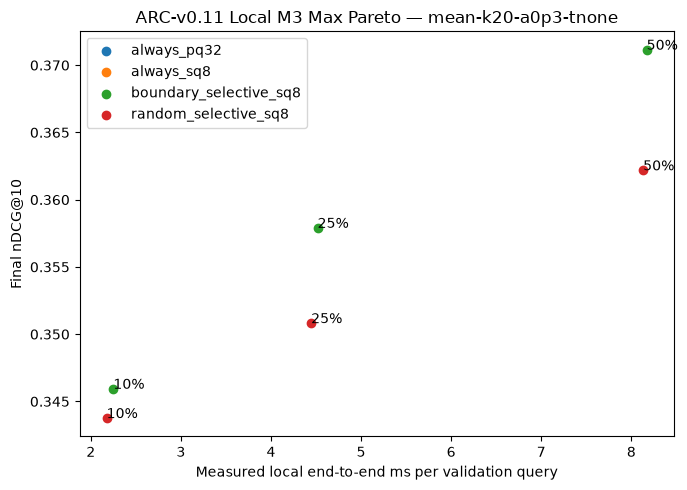

Saved: /Users/ravan/ARC_benchmark/arc-v0/system-cost-pareto-audit-v011-local-m3max/20260817-111833/v011_local_quality_vs_latency-mean-k20-a0p3-tnone.png


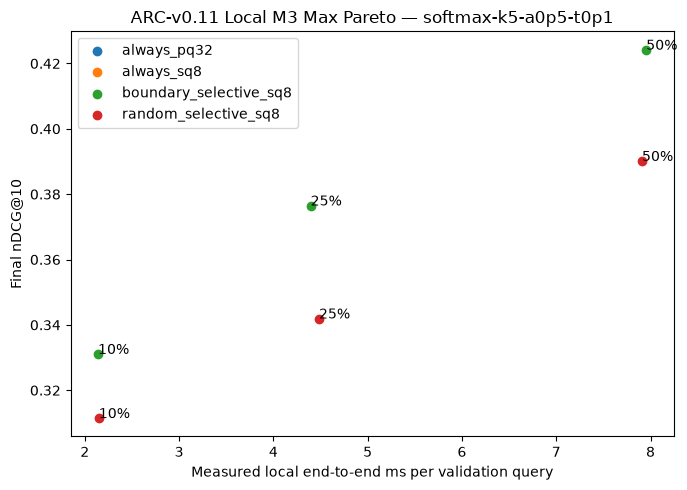

Saved: /Users/ravan/ARC_benchmark/arc-v0/system-cost-pareto-audit-v011-local-m3max/20260817-111833/v011_local_quality_vs_latency-softmax-k5-a0p5-t0p1.png


In [23]:
for ck in pareto_df["config_key"].unique():
    sub = pareto_df[
        pareto_df["config_key"] == ck
    ].copy()

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    for policy, g in sub.groupby("policy"):
        ax.scatter(
            g["mean_ms_per_query"],
            g["mean_final_ndcg"],
            label=policy,
        )

        for _, r in g.iterrows():
            if not pd.isna(r["budget"]):
                ax.annotate(
                    f"{100*float(r['budget']):.0f}%",
                    (
                        r["mean_ms_per_query"],
                        r["mean_final_ndcg"],
                    ),
                )

    ax.set_xlabel(
        "Measured local end-to-end ms per validation query"
    )

    ax.set_ylabel(
        "Final nDCG@10"
    )

    ax.set_title(
        f"ARC-v0.11 Local M3 Max Pareto — {ck}"
    )

    ax.legend()

    fig.tight_layout()

    path = OUT / f"v011_local_quality_vs_latency-{ck}.png"

    fig.savefig(
        path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", path)


## 20. Final report and SHA-256 seal


In [24]:
report = {
    "status": "ARC_V011_LOCAL_M3MAX_SYSTEM_COST_PARETO_COMPLETE",
    "protocol_sha256": protocol_sha,
    "source_v010_report_sha256": sha256_file(V010_REPORT),
    "selector_assignment_sha256": sha256_file(V010_SELECTOR_ASSIGNMENTS),
    "selector_audit_sha256": sha256_file(V010_SELECTOR_AUDIT),
    "selector_provenance": "deterministic post-hoc reconstruction from frozen ARC-v0.9/v0.10 artifacts",
    "hardware": hardware,
    "validation_queries": len(Q_VAL),
    "repetitions": REPETITIONS,
    "warmup_queries": WARMUP_QUERIES,
    "index_load_seconds": index_load_seconds,
    "index_memory": memory_df.to_dict(orient="records"),
    "retrieval_microbenchmark": micro_df.to_dict(orient="records"),
    "query_latency_summary": latency_df.to_dict(orient="records"),
    "policy_latency_summary": policy_summary.to_dict(orient="records"),
    "primary_25pct_system_decision": primary_df.to_dict(orient="records"),
    "test_accessed": False,
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
}

REPORT = OUT / "report.json"

REPORT.write_text(
    json.dumps(
        report,
        indent=2,
        default=float,
    ),
    encoding="utf-8",
)

report_sha = sha256_file(REPORT)

(OUT / "REPORT_SHA256.txt").write_text(
    report_sha + "\n",
    encoding="utf-8",
)

print("Saved:", OUT)
print("Report SHA-256:", report_sha)
display(primary_df)


Saved: /Users/ravan/ARC_benchmark/arc-v0/system-cost-pareto-audit-v011-local-m3max/20260817-111833
Report SHA-256: d6b49ced27062a76d64b234e8711c652a9d293f464d7a747a6ad2ab5ef13c5f8


,config_key,selective_ndcg,recovery_fraction,selective_mean_seconds,random_mean_seconds,always_pq32_mean_seconds,always_sq8_mean_seconds,selective_qps,selective_peak_rss_gib,latency_ratio_vs_pq32,fraction_of_always_sq8_extra_runtime
0,mean-k20-a0p3-tnone,0.357904,0.411425,12.170428,11.977410,1.960635,39.587094,221.360219,3.032693,6.207391,0.271346
1,softmax-k5-a0p5-t0p1,0.376525,0.440812,11.840264,12.078356,1.841870,39.011016,227.535020,3.032098,6.428391,0.268997


In [1]:
# ============================================================
# ARC-v0.11.1 — FINAL QUALITY × SYSTEM-COST AUDIT
#
# Purpose
# -------
# 1. Reuse sealed ARC-v0.10 quality evidence.
# 2. Reuse completed ARC-v0.11 M3 Max system measurements.
# 3. Repair the baseline quality merge by canonicalizing budgets:
#       always_pq32 -> 0.0
#       always_sq8  -> 1.0
# 4. Do NOT rerun retrieval / policy benchmarks.
# 5. Seal repaired Pareto + primary 25% aggregate artifacts.
# ============================================================

from pathlib import Path
import json
import hashlib
import platform

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

V010_RUN = (
    Path.home()
    / "ARC_benchmark"
    / "arc-v0"
    / "boundary-aware-selective-fidelity-v010"
    / "20260816-205143"
)

V011_RUN = (
    Path.home()
    / "ARC_benchmark"
    / "arc-v0"
    / "system-cost-pareto-audit-v011-local-m3max"
    / "20260817-111833"
)

V0111_RUN = (
    Path.home()
    / "ARC_benchmark"
    / "arc-v0"
    / "system-cost-pareto-audit-v0111-final"
    / "20260817-final"
)

V0111_RUN.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()

    with path.open("rb") as f:
        while True:
            block = f.read(1024 * 1024)

            if not block:
                break

            h.update(block)

    return h.hexdigest()


def canonical_budget(policy, budget):
    if policy == "always_pq32":
        return 0.0

    if policy == "always_sq8":
        return 1.0

    if pd.isna(budget):
        raise ValueError(
            f"Unexpected NaN budget for policy={policy!r}"
        )

    return float(budget)


# ============================================================
# 0. Source-artifact integrity gate
# ============================================================

required = {
    # v0.10 quality
    "v010_mitigation":
        V010_RUN / "mitigation_summary.csv",

    "v010_primary":
        V010_RUN / "primary_25pct_budget_decision.csv",

    "v010_report":
        V010_RUN / "report.json",

    # v0.11 systems
    "v011_raw":
        V011_RUN / "v011_local_policy_benchmark_raw.csv",

    "v011_latency":
        V011_RUN / "v011_local_policy_latency_summary.csv",

    "v011_pareto":
        V011_RUN / "v011_local_pareto_summary.csv",

    "v011_primary":
        V011_RUN / "v011_local_primary_25pct_system_decision.csv",

    "v011_relative":
        V011_RUN / "v011_local_relative_cost_summary.csv",

    "v011_report":
        V011_RUN / "report.json",
}

for name, path in required.items():
    print(
        f"{name:18s}",
        "PASS" if path.is_file() else "MISSING",
        path,
    )

    assert path.is_file(), path


print(
    "\nSOURCE ARTIFACT PATHS — PASS"
)


# ============================================================
# 1. Load sealed v0.10 quality evidence
# ============================================================

mitigation_summary = pd.read_csv(
    required["v010_mitigation"]
)

primary_v010 = pd.read_csv(
    required["v010_primary"]
)

with required[
    "v010_report"
].open(
    "r",
    encoding="utf-8",
) as f:
    v010_report = json.load(f)


# ============================================================
# 2. Load completed v0.11 systems evidence
# ============================================================

policy_raw = pd.read_csv(
    required["v011_raw"]
)

policy_summary = pd.read_csv(
    required["v011_latency"]
)

pareto_v011 = pd.read_csv(
    required["v011_pareto"]
)

primary_system = pd.read_csv(
    required["v011_primary"]
)

relative_cost = pd.read_csv(
    required["v011_relative"]
)

with required[
    "v011_report"
].open(
    "r",
    encoding="utf-8",
) as f:
    v011_report = json.load(f)


print(
    "\nv0.10 status:",
    v010_report.get("status"),
)

print(
    "v0.11 status:",
    v011_report.get("status"),
)


assert (
    v010_report.get("status")
    ==
    "ARC_V010_BOUNDARY_AWARE_SELECTIVE_FIDELITY_COMPLETE"
)

assert (
    v011_report.get("status")
    ==
    "ARC_V011_LOCAL_M3MAX_SYSTEM_COST_PARETO_COMPLETE"
)

print(
    "SOURCE REPORT STATUS — PASS"
)


# ============================================================
# 3. Sanity-check expected experiment structure
# ============================================================

EXPECTED_CONFIGS = {
    "mean-k20-a0p3-tnone",
    "softmax-k5-a0p5-t0p1",
}

EXPECTED_POLICIES = {
    "always_pq32",
    "always_sq8",
    "random_selective_sq8",
    "boundary_selective_sq8",
}

assert set(
    mitigation_summary["config_key"].unique()
) == EXPECTED_CONFIGS

assert set(
    mitigation_summary["policy"].unique()
) == EXPECTED_POLICIES

assert len(
    mitigation_summary
) == 16

assert len(
    pareto_v011
) == 16

print(
    "EXPERIMENT STRUCTURE — PASS"
)


# ============================================================
# 4. Canonicalize budget keys
# ============================================================

quality = (
    mitigation_summary
    .copy()
)

quality["budget_key"] = [
    canonical_budget(
        policy,
        budget,
    )
    for policy, budget in zip(
        quality["policy"],
        quality["budget"],
    )
]


systems = (
    pareto_v011
    .copy()
)

systems["budget_key"] = [
    canonical_budget(
        policy,
        budget,
    )
    for policy, budget in zip(
        systems["policy"],
        systems["budget"],
    )
]


# Ensure merge keys are unique before joining.
merge_keys = [
    "config_key",
    "policy",
    "budget_key",
]

assert not quality.duplicated(
    merge_keys
).any()

assert not systems.duplicated(
    merge_keys
).any()

print(
    "CANONICAL BUDGET KEYS — PASS"
)


# ============================================================
# 5. Repair v0.10 quality -> v0.11 system-cost merge
# ============================================================

quality_fields = [
    "mean_final_ndcg",
    "extra_sq8_fraction",
    "recovery_fraction",
    "delta_vs_always_pq32",
    "delta_vs_always_pq32_ci_low",
    "delta_vs_always_pq32_ci_high",
    "delta_vs_random",
    "delta_vs_random_ci_low",
    "delta_vs_random_ci_high",
]


# Remove original broken / incomplete quality fields from the
# v0.11 Pareto table before replacing them from sealed v0.10.
systems_clean = systems.drop(
    columns=[
        col
        for col in quality_fields
        if col in systems.columns
    ],
    errors="ignore",
)


quality_for_merge = quality[
    merge_keys
    + quality_fields
].copy()


pareto_fixed = (
    systems_clean
    .merge(
        quality_for_merge,
        on=merge_keys,
        how="left",
        validate="one_to_one",
    )
)


# ============================================================
# 6. Strong quality-join completeness checks
# ============================================================

assert len(
    pareto_fixed
) == 16

assert (
    pareto_fixed[
        "mean_final_ndcg"
    ]
    .notna()
    .all()
)

assert (
    pareto_fixed[
        "extra_sq8_fraction"
    ]
    .notna()
    .all()
)

assert (
    pareto_fixed[
        "recovery_fraction"
    ]
    .notna()
    .all()
)


print(
    "\nQUALITY JOIN COMPLETE — PASS"
)


display(
    pareto_fixed[
        [
            "config_key",
            "policy",
            "budget_key",
            "mean_final_ndcg",
            "recovery_fraction",
            "mean_total_seconds",
            "mean_qps",
            "mean_peak_rss_gib",
        ]
    ]
)


# ============================================================
# 7. Verify exact sealed baseline qualities
# ============================================================

expected_baselines = {
    (
        "mean-k20-a0p3-tnone",
        "always_pq32",
    ): 0.338249,

    (
        "mean-k20-a0p3-tnone",
        "always_sq8",
    ): 0.386022,

    (
        "softmax-k5-a0p5-t0p1",
        "always_pq32",
    ): 0.292336,

    (
        "softmax-k5-a0p5-t0p1",
        "always_sq8",
    ): 0.483323,
}


for (
    config_key,
    policy,
), expected_value in expected_baselines.items():

    rows = pareto_fixed.loc[
        (
            pareto_fixed[
                "config_key"
            ]
            == config_key
        )
        &
        (
            pareto_fixed[
                "policy"
            ]
            == policy
        ),
        "mean_final_ndcg",
    ]

    assert len(
        rows
    ) == 1

    value = float(
        rows.iloc[0]
    )

    print(
        f"{config_key:27s}",
        f"{policy:14s}",
        f"{value:.9f}",
    )

    assert np.isclose(
        value,
        expected_value,
        atol=1e-6,
    )


print(
    "\nBASELINE QUALITY RECOVERY — PASS"
)


# ============================================================
# 8. Build final primary 25% quality-cost table
# ============================================================

primary_quality = mitigation_summary[
    (
        mitigation_summary[
            "policy"
        ]
        ==
        "boundary_selective_sq8"
    )
    &
    np.isclose(
        mitigation_summary[
            "budget"
        ],
        0.25,
    )
].copy()


quality_primary_fields = [
    "config_key",
    "mean_final_ndcg",
    "extra_sq8_fraction",
    "recovery_fraction",
    "delta_vs_random",
    "delta_vs_random_ci_low",
    "delta_vs_random_ci_high",
]


primary_quality = primary_quality[
    quality_primary_fields
]


assert len(
    primary_quality
) == 2

assert set(
    primary_quality[
        "config_key"
    ]
) == EXPECTED_CONFIGS


primary_system_clean = (
    primary_system
    .drop(
        columns=[
            col
            for col
            in quality_primary_fields[1:]
            if col
            in primary_system.columns
        ],
        errors="ignore",
    )
)


primary_final = (
    primary_system_clean
    .merge(
        primary_quality,
        on="config_key",
        how="left",
        validate="one_to_one",
    )
)


assert len(
    primary_final
) == 2

assert (
    primary_final[
        "mean_final_ndcg"
    ]
    .notna()
    .all()
)

assert (
    primary_final[
        "recovery_fraction"
    ]
    > 0
).all()

assert (
    primary_final[
        "delta_vs_random_ci_low"
    ]
    > 0
).all()

assert (
    primary_final[
        "fraction_of_always_sq8_extra_runtime"
    ]
    < 0.30
).all()


print(
    "\nPRIMARY 25% FINAL DECISION — PASS"
)


display(
    primary_final
)


# ============================================================
# 9. Compute paper-facing Pareto efficiency
# ============================================================

primary_final[
    "recovery_per_sq8_extra_runtime_fraction"
] = (
    primary_final[
        "recovery_fraction"
    ]
    /
    primary_final[
        "fraction_of_always_sq8_extra_runtime"
    ]
)


assert np.isfinite(
    primary_final[
        "recovery_per_sq8_extra_runtime_fraction"
    ]
).all()

assert (
    primary_final[
        "recovery_per_sq8_extra_runtime_fraction"
    ]
    > 1.0
).all()


print(
    "\nPARETO EFFICIENCY — PASS"
)


paper_view_cols = [
    "config_key",
    "mean_final_ndcg",
    "recovery_fraction",
    "delta_vs_random",
    "delta_vs_random_ci_low",
    "delta_vs_random_ci_high",
    "selective_mean_seconds",
    "random_mean_seconds",
    "always_pq32_mean_seconds",
    "always_sq8_mean_seconds",
    "fraction_of_always_sq8_extra_runtime",
    "recovery_per_sq8_extra_runtime_fraction",
]

display(
    primary_final[
        paper_view_cols
    ]
)


# ============================================================
# 10. Save repaired aggregates
# ============================================================

PARETO_OUT = (
    V0111_RUN
    / "v0111_final_pareto_summary.csv"
)

PRIMARY_OUT = (
    V0111_RUN
    / "v0111_final_primary_25pct_decision.csv"
)


pareto_fixed.to_csv(
    PARETO_OUT,
    index=False,
)

primary_final.to_csv(
    PRIMARY_OUT,
    index=False,
)


# ============================================================
# 11. Generate deterministic v0.11.1 audit report
# ============================================================

report = {
    "status":
        "ARC_V0111_FINAL_QUALITY_COST_AUDIT_COMPLETE",

    "audit_scope":
        (
            "Post-v0.11 deterministic repair of the "
            "sealed v0.10 quality-to-v0.11 measured-cost "
            "aggregate join. No retrieval, feedback-policy, "
            "or system benchmark was rerun."
        ),

    "source_v010_report_sha256":
        sha256_file(
            required[
                "v010_report"
            ]
        ),

    "source_v011_report_sha256":
        sha256_file(
            required[
                "v011_report"
            ]
        ),

    "source_v011_policy_raw_sha256":
        sha256_file(
            required[
                "v011_raw"
            ]
        ),

    "quality_rows":
        int(
            len(
                mitigation_summary
            )
        ),

    "pareto_rows":
        int(
            len(
                pareto_fixed
            )
        ),

    "primary_rows":
        int(
            len(
                primary_final
            )
        ),

    "primary_all_positive_vs_random":
        bool(
            (
                primary_final[
                    "delta_vs_random_ci_low"
                ]
                > 0
            ).all()
        ),

    "primary_under_30pct_sq8_extra_runtime":
        bool(
            (
                primary_final[
                    "fraction_of_always_sq8_extra_runtime"
                ]
                < 0.30
            ).all()
        ),

    "primary_recovery_exceeds_runtime_fraction":
        bool(
            (
                primary_final[
                    "recovery_per_sq8_extra_runtime_fraction"
                ]
                > 1.0
            ).all()
        ),

    "machine":
        platform.machine(),

    "interpretation_constraint":
        (
            "System-cost values are measurements from a "
            "single Apple M3 Max CPU environment and must "
            "not be interpreted as universal production "
            "latency or throughput."
        ),
}


REPORT_OUT = (
    V0111_RUN
    / "v0111_final_audit_report.json"
)


with REPORT_OUT.open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        report,
        f,
        indent=2,
        sort_keys=True,
    )


# ============================================================
# 12. SHA-256 sealing
# ============================================================

report_sha = sha256_file(
    REPORT_OUT
)


REPORT_SHA_OUT = (
    V0111_RUN
    / "V0111_FINAL_REPORT_SHA256.txt"
)


with REPORT_SHA_OUT.open(
    "w",
    encoding="utf-8",
) as f:
    f.write(
        f"{report_sha}  "
        f"{REPORT_OUT.name}\n"
    )


artifact_hashes = {
    PARETO_OUT.name:
        sha256_file(
            PARETO_OUT
        ),

    PRIMARY_OUT.name:
        sha256_file(
            PRIMARY_OUT
        ),

    REPORT_OUT.name:
        report_sha,
}


HASH_MANIFEST_OUT = (
    V0111_RUN
    / "V0111_ARTIFACT_SHA256.json"
)


with HASH_MANIFEST_OUT.open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        artifact_hashes,
        f,
        indent=2,
        sort_keys=True,
    )


# ============================================================
# 13. Read-back verification
# ============================================================

pareto_check = pd.read_csv(
    PARETO_OUT
)

primary_check = pd.read_csv(
    PRIMARY_OUT
)

with REPORT_OUT.open(
    "r",
    encoding="utf-8",
) as f:
    report_check = json.load(f)


assert len(
    pareto_check
) == 16

assert len(
    primary_check
) == 2

assert (
    pareto_check[
        "mean_final_ndcg"
    ]
    .notna()
    .all()
)

assert (
    report_check[
        "status"
    ]
    ==
    "ARC_V0111_FINAL_QUALITY_COST_AUDIT_COMPLETE"
)

assert (
    sha256_file(
        REPORT_OUT
    )
    ==
    report_sha
)


print(
    "\nSEALED ARTIFACT READ-BACK — PASS"
)


# ============================================================
# 14. Final output
# ============================================================

print()
print("=" * 88)

print(
    "ARC-v0.11.1 FINAL AUDIT — PASS"
)

print(
    "Output directory:",
    V0111_RUN,
)

print(
    "Report SHA-256:",
    report_sha,
)

print(
    "Pareto SHA-256:",
    artifact_hashes[
        PARETO_OUT.name
    ],
)

print(
    "Primary SHA-256:",
    artifact_hashes[
        PRIMARY_OUT.name
    ],
)

print("=" * 88)


display(
    primary_final[
        paper_view_cols
    ]
)

v010_mitigation    PASS /Users/ravan/ARC_benchmark/arc-v0/boundary-aware-selective-fidelity-v010/20260816-205143/mitigation_summary.csv
v010_primary       PASS /Users/ravan/ARC_benchmark/arc-v0/boundary-aware-selective-fidelity-v010/20260816-205143/primary_25pct_budget_decision.csv
v010_report        PASS /Users/ravan/ARC_benchmark/arc-v0/boundary-aware-selective-fidelity-v010/20260816-205143/report.json
v011_raw           PASS /Users/ravan/ARC_benchmark/arc-v0/system-cost-pareto-audit-v011-local-m3max/20260817-111833/v011_local_policy_benchmark_raw.csv
v011_latency       PASS /Users/ravan/ARC_benchmark/arc-v0/system-cost-pareto-audit-v011-local-m3max/20260817-111833/v011_local_policy_latency_summary.csv
v011_pareto        PASS /Users/ravan/ARC_benchmark/arc-v0/system-cost-pareto-audit-v011-local-m3max/20260817-111833/v011_local_pareto_summary.csv
v011_primary       PASS /Users/ravan/ARC_benchmark/arc-v0/system-cost-pareto-audit-v011-local-m3max/20260817-111833/v011_local_primary_25pct

,config_key,policy,budget_key,mean_final_ndcg,recovery_fraction,mean_total_seconds,mean_qps,mean_peak_rss_gib
0,mean-k20-a0p3-tnone,always_pq32,0.00,0.338249,0.000000,1.960635,1376.384856,3.035364
1,mean-k20-a0p3-tnone,always_sq8,1.00,0.386022,1.000000,39.587094,68.058448,2.997977
2,mean-k20-a0p3-tnone,boundary_selective_sq8,0.10,0.345939,0.160977,6.062740,444.834299,3.018610
3,mean-k20-a0p3-tnone,boundary_selective_sq8,0.25,0.357904,0.411425,12.170428,221.360219,3.032693
4,mean-k20-a0p3-tnone,boundary_selective_sq8,0.50,0.371147,0.688631,22.010437,122.400693,3.023581
5,mean-k20-a0p3-tnone,random_selective_sq8,0.10,0.343762,0.115403,5.861201,459.826869,3.006351
6,mean-k20-a0p3-tnone,random_selective_sq8,0.25,0.350820,0.263140,11.977410,224.952538,3.038464
7,mean-k20-a0p3-tnone,random_selective_sq8,0.50,0.362178,0.500903,21.906310,122.986412,3.033679
8,softmax-k5-a0p5-t0p1,always_pq32,0.00,0.292336,0.000000,1.841870,1481.230340,2.996542
9,softmax-k5-a0p5-t0p1,always_sq8,1.00,0.483323,1.000000,39.011016,69.059667,3.020026


mean-k20-a0p3-tnone         always_pq32    0.338248640
mean-k20-a0p3-tnone         always_sq8     0.386021763
softmax-k5-a0p5-t0p1        always_pq32    0.292335689
softmax-k5-a0p5-t0p1        always_sq8     0.483323306

BASELINE QUALITY RECOVERY — PASS

PRIMARY 25% FINAL DECISION — PASS


,config_key,selective_ndcg,selective_mean_seconds,random_mean_seconds,always_pq32_mean_seconds,always_sq8_mean_seconds,selective_qps,selective_peak_rss_gib,latency_ratio_vs_pq32,fraction_of_always_sq8_extra_runtime,mean_final_ndcg,extra_sq8_fraction,recovery_fraction,delta_vs_random,delta_vs_random_ci_low,delta_vs_random_ci_high
0,mean-k20-a0p3-tnone,0.357904,12.170428,11.977410,1.960635,39.587094,221.360219,3.032693,6.207391,0.271346,0.357904,0.264662,0.411425,0.007084,0.003560,0.010677
1,softmax-k5-a0p5-t0p1,0.376525,11.840264,12.078356,1.841870,39.011016,227.535020,3.032098,6.428391,0.268997,0.376525,0.264662,0.440812,0.034576,0.026755,0.042598



PARETO EFFICIENCY — PASS


,config_key,mean_final_ndcg,recovery_fraction,delta_vs_random,delta_vs_random_ci_low,delta_vs_random_ci_high,selective_mean_seconds,random_mean_seconds,always_pq32_mean_seconds,always_sq8_mean_seconds,fraction_of_always_sq8_extra_runtime,recovery_per_sq8_extra_runtime_fraction
0,mean-k20-a0p3-tnone,0.357904,0.411425,0.007084,0.003560,0.010677,12.170428,11.977410,1.960635,39.587094,0.271346,1.516238
1,softmax-k5-a0p5-t0p1,0.376525,0.440812,0.034576,0.026755,0.042598,11.840264,12.078356,1.841870,39.011016,0.268997,1.638726



SEALED ARTIFACT READ-BACK — PASS

ARC-v0.11.1 FINAL AUDIT — PASS
Output directory: /Users/ravan/ARC_benchmark/arc-v0/system-cost-pareto-audit-v0111-final/20260817-final
Report SHA-256: e01c4145dfca90ac289bbdd8402b9c4497db9c88b09c28dba37982e4dacd5973
Pareto SHA-256: e7202ebf7489faf4ab8e8fea7fc36840df5786b123d20201d8deb8c9c5e286d1
Primary SHA-256: 4900f4e5d843a6c88eae1a240c0c0ea9d0c4741198b8dc2155e17dbcb0317f6f


,config_key,mean_final_ndcg,recovery_fraction,delta_vs_random,delta_vs_random_ci_low,delta_vs_random_ci_high,selective_mean_seconds,random_mean_seconds,always_pq32_mean_seconds,always_sq8_mean_seconds,fraction_of_always_sq8_extra_runtime,recovery_per_sq8_extra_runtime_fraction
0,mean-k20-a0p3-tnone,0.357904,0.411425,0.007084,0.003560,0.010677,12.170428,11.977410,1.960635,39.587094,0.271346,1.516238
1,softmax-k5-a0p5-t0p1,0.376525,0.440812,0.034576,0.026755,0.042598,11.840264,12.078356,1.841870,39.011016,0.268997,1.638726


## Interpretation discipline

This notebook provides a **controlled single-machine Apple M3 Max CPU benchmark**.

It must not be described as a universal production/data-center latency result.

Strong evidence would be:

- boundary-aware selective policies lie near the quality–latency Pareto frontier;
- the primary 25% policy uses substantially less measured extra runtime than Always-SQ8;
- recovered utility is disproportionately large relative to extra runtime;
- repeated-run variability is small.

If sparse SQ8 allocation costs almost as much as Always-SQ8, report that directly. That would show
that query fraction is a poor proxy for implementation-level runtime cost.

The next external-validity benchmark, if available, should use a separate x86 CPU server without
changing the frozen ARC-v0.10 policy.
